In [12]:
import yaml, torch, sys, json, random, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from types import SimpleNamespace
from PIL import Image, ImageFont, ImageDraw
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split
from torchvision import datasets, transforms
import torchvision.transforms.functional as TF
sys.path.insert(0, '../../')
# import random
from utils.train_model import run_experiment, set_seed, get_device
from collections import defaultdict



In [89]:
def to_namespace(d):
    if isinstance(d, dict):
        return SimpleNamespace(**{k: to_namespace(v) for k, v in d.items()})
    return d

with open('../../configs/defaults.yaml') as f:
    config = yaml.safe_load(f)

with open('../../configs/EX_03_05.yaml') as f:
    config.update(yaml.safe_load(f))

config = to_namespace(config)
set_seed(config.seed)
device = get_device()
RAW_DIR  = Path(config.raw_dir)
GRAD_DIR = Path(config.grad_dir)
data_dir = Path('./EX_03_05/Raw/')

[device] using cuda


# idea

so here we take the full glyph set from ex_03_04, and we use the generated as the training for the first part of the 2-model idea. basically, the prep network will generated a good background, the hider network will bury the code for the blur. 

In [79]:
def box_blur(x, kernel_size=9):
    channels = x.shape[1]
    kernel = torch.ones(channels, 1, kernel_size, kernel_size, 
                        device=x.device) / (kernel_size ** 2)
    return F.conv2d(x, kernel, padding=kernel_size//2, groups=channels)

def bandwtn(image):
    # image shape: (B, C, H, W)
    if image.shape[1] == 3:
        gray = (
            0.299 * image[:, 0:1] +
            0.587 * image[:, 1:2] +
            0.114 * image[:, 2:3]
        )
        # repeat to 3 channels to match input
        return gray.repeat(1, 3, 1, 1)
    
    elif image.shape[1] == 1:
        # already grayscale, just return
        return image
    
    else:
        raise ValueError(f"Unsupported number of channels: {image.shape[1]}")

def alpha_combine(b, i):
    alpha = i.expand_as(b)
    comp = alpha * i.expand_as(b) + (1 - alpha) * b
    return comp
    
def additive_combine(b, i):
    """
    b: (B, 3, H, W) background
    i: (B, 1, H, W) or (B, 3, H, W) digit
    returns: (B, 3, H, W) composite, clamped
    """
    return (b + i.expand_as(b)).clamp(0, 1)


def blur(x, blur_type, kernel_size=3, **kwargs):
    if blur_type == "box":
        return box_blur(x, kernel_size=kernel_size, **kwargs)
    elif blur_type == "gaussian":
        return TF.gaussian_blur(x, kernel_size=[kernel_size, kernel_size], 
                                sigma=kwargs.get("sigma", 1.0))
    else:
        raise ValueError(f"unknown blur_type: {blur_type}")

# Prep Model

In [80]:
DIGITS    = list("0123456789")                       # 10 — keep all
UPPERCASE = list("AEFHKLMNPRTVWXY")                   # 15 — dropped B(8) C(O) D(O) G(6) I(1) J(I) O(0) Q(O) S(5) U(V) Z(2)
LOWERCASE = list("adefhnrt")                          # 8  — EMNIST-distinct minus b(8) g(9) q(9)
FMNIST    = ["tshirt","trouser","pullover","dress","coat",
             "sandal","shirt","sneaker","bag","ankleboot"]  # 10
SYMBOLS   = list("★♥●▲■◆✚▼◀▶⬟⬢")                    # 12

CLASSES = (
    [("digit",  c) for c in DIGITS]    +
    [("upper",  c) for c in UPPERCASE] +
    [("lower",  c) for c in LOWERCASE] +
    [("fmnist", i) for i in range(len(FMNIST))] +
    [("symbol", c) for c in SYMBOLS]
)
NUM_CLASSES = len(CLASSES)  # 55

# Each class draws from one or more sources, picked uniformly per sample.
# Lowercase font renders are skipped — at 28px they're too small relative
# to uppercase, which gives them an unfair handicap in the diagnostic.
SOURCES_FOR_KIND = {
    "digit":  ["mnist", "font_inter", "font_serif"],
    "upper":  ["emnist", "font_inter", "font_serif"],
    "lower":  ["emnist"],
    "fmnist": ["fmnist"],
    "symbol": ["font_symbols"],
}

# EMNIST balanced label → char mapping (47 classes)
EMNIST_BALANCED_CHARS = (
    list("0123456789") +
    list("ABCDEFGHIJKLMNOPQRSTUVWXYZ") +
    list("abdefghnqrt")
)

FONT_PATHS = {
    "inter":   "../../shared_models/assets/Helvetica-Bold.ttf",
    "serif":   "../../shared_models/assets/AppleGaramond-Bold.ttf",
    "symbols": "../../shared_models/assets/NotoSansSymbols2-Regular.ttf",
}

def _idx_by_label(targets, label_to_key):
    idx = {k: [] for k in label_to_key.values()}
    arr = targets.numpy() if torch.is_tensor(targets) else targets
    for i, lbl in enumerate(arr):
        key = label_to_key.get(int(lbl))
        if key is not None:
            idx[key].append(i)
    return idx

def _render_font_glyph(char, font, size):
    img  = Image.new("L", (size, size), 0)
    draw = ImageDraw.Draw(img)
    bbox = draw.textbbox((0, 0), char, font=font)
    x = (size - (bbox[2] - bbox[0])) // 2 - bbox[0]
    y = (size - (bbox[3] - bbox[1])) // 2 - bbox[1]
    draw.text((x, y), char, fill=255, font=font)
    return TF.to_tensor(img)  # (1, size, size)

def _emnist_fix(pil_img):
    # EMNIST is stored transposed; this is the canonical un-transpose.
    return pil_img.transpose(Image.TRANSPOSE)

def glyph_bgrnd(size, bg_type):
    if bg_type == "blank":
        return torch.zeros(3, size, size)
    raise ValueError(f"unknown bg_type: {bg_type}")

class UnifiedGlyphDataset(Dataset):
    def __init__(self, num_samples=60000, size=28, bg_type="blank"):
        self.num_samples = num_samples
        self.size = size
        self.bg_type = bg_type

        # Raw datasets (no transform — we handle PIL → tensor by hand)
        self.mnist  = datasets.MNIST(root="../../data/", train=True, download=True)
        self.emnist = datasets.EMNIST(root="../../data/", split="balanced",
                                       train=True, download=True)
        self.fmnist = datasets.FashionMNIST(root="../../data/", train=True, download=True)

        # Per-class index lookups (built once via .targets, fast)
        self.mnist_idx  = _idx_by_label(
            self.mnist.targets,
            {i: str(i) for i in range(10)},
        )
        emnist_label_to_char = {
            i: c for i, c in enumerate(EMNIST_BALANCED_CHARS)
            if c in set(UPPERCASE + LOWERCASE)
        }
        self.emnist_idx = _idx_by_label(self.emnist.targets, emnist_label_to_char)
        self.fmnist_idx = _idx_by_label(
            self.fmnist.targets,
            {i: i for i in range(10)},
        )

        # Fonts — sized per source so glyphs fit the 28px box even when bold
        self.fonts = {
            "inter":   ImageFont.truetype(FONT_PATHS["inter"],   size=int(size * 0.95)),
            "serif":   ImageFont.truetype(FONT_PATHS["serif"],   size=int(size * 0.95)),
            "symbols": ImageFont.truetype(FONT_PATHS["symbols"], size=int(size * 0.80)),
        }

    def __len__(self):
        return self.num_samples

    def _get_glyph(self, kind, key):
        source = random.choice(SOURCES_FOR_KIND[kind])

        if source == "mnist":
            i = random.choice(self.mnist_idx[key])
            pil, _ = self.mnist[i]
            return TF.to_tensor(pil)
        if source == "emnist":
            i = random.choice(self.emnist_idx[key])
            pil, _ = self.emnist[i]
            return TF.to_tensor(_emnist_fix(pil))
        if source == "fmnist":
            i = random.choice(self.fmnist_idx[key])
            pil, _ = self.fmnist[i]
            return TF.to_tensor(pil)
        if source == "font_inter":
            return _render_font_glyph(key, self.fonts["inter"], self.size)
        if source == "font_serif":
            return _render_font_glyph(key, self.fonts["serif"], self.size)
        if source == "font_symbols":
            return _render_font_glyph(key, self.fonts["symbols"], self.size)
        raise ValueError(f"unknown source: {source}")

    def __getitem__(self, idx):
        label = random.randrange(NUM_CLASSES)
        kind, key = CLASSES[label]
        glyph = self._get_glyph(kind, key)

        background   = glyph_bgrnd(self.size, self.bg_type)
        comp         = torch.cat([background, glyph], dim=0)
        target_color = torch.rand(3)
        return comp, label, target_color



# ============================================================
# n = 100
n = 60000
ex03_05_trainset = UnifiedGlyphDataset(num_samples=n)
train_size = int(0.9 * n)
val_size   = n - train_size
train_set, val_set = random_split(
    ex03_05_trainset, [train_size, val_size],
    generator=torch.Generator().manual_seed(config.seed)
)
ex03_05_trainloader = DataLoader(train_set, batch_size=config.batch_size, shuffle=True)
ex03_05_valloader   = DataLoader(val_set,   batch_size=config.batch_size)

In [44]:
# this loads the dataset that ex_03_04 made, which we'll use as "gold standard" for 05


class BootstrapWrapper(Dataset):
    """
    Wraps the unified glyph dataset for painter bootstrapping. Each sample
    additionally returns a randomly-selected prior image for its class.
    The original dataset is unchanged; this wrapper exists only for EX_03_05a.
    """
    def __init__(self, base_dataset, prior_imgs, prior_labels):
        self.base = base_dataset
        
        # Stack priors into (num_classes, samples_per_class, C, H, W)
        from collections import defaultdict
        by_class = defaultdict(list)
        for img, lbl in zip(prior_imgs, prior_labels):
            by_class[int(lbl)].append(img)
        
        max_count = max(len(v) for v in by_class.values())
        num_classes = max(by_class.keys()) + 1
        sample_shape = next(iter(by_class.values()))[0].shape
        
        self.bank = torch.zeros(num_classes, max_count, *sample_shape)
        self.counts = torch.zeros(num_classes, dtype=torch.long)
        for c, imgs in by_class.items():
            self.counts[c] = len(imgs)
            self.bank[c, :len(imgs)] = torch.stack(imgs)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        comp, label, target_color = self.base[idx]
        # One random prior for this class
        n = self.counts[int(label)].item()
        prior_idx = torch.randint(0, n, (1,)).item()
        prior = self.bank[int(label), prior_idx]
        return comp, label, target_color, prior


# ============================================================
bank = torch.load("data/ex03_05_prior_bank.pt", weights_only=True)
ex03_05a_dataset = BootstrapWrapper(ex03_05_trainset, bank["imgs"], bank["labels"])

# n=100
n=60000
train_size_a = int(0.9 * len(ex03_05_dataset))
val_size_a   = len(ex03_05_dataset) - train_size
train_set_a, val_set_a = random_split(
    ex03_05a_dataset, [train_size_a, val_size_a],
    generator=torch.Generator().manual_seed(config.seed)
)
ex03_05a_trainloader = DataLoader(train_set_a, batch_size=config.batch_size, shuffle=True)
ex03_05a_valloader   = DataLoader(val_set_a,   batch_size=config.batch_size)



In [45]:
from transformers import AutoImageProcessor, SiglipForImageClassification

style_model = SiglipForImageClassification.from_pretrained("prithivMLmods/WikiArt-Style").to(device)
style_processor = AutoImageProcessor.from_pretrained("prithivMLmods/WikiArt-Style")
style_model.eval()

POLLOCK_LABELS = [1, 3]  # "Abstract Expressionism", "Action painting" — verify indices

def pollock_loss(generated):
    # generated: (B, 3, 28, 28), needs upscaling for the processor
    upscaled = F.interpolate(generated, size=(224, 224), mode="bilinear")
    inputs = style_processor(images=upscaled, return_tensors="pt", do_rescale=False).to(device)
    with torch.no_grad():  # freeze, we just want the gradient through the score
        logits = style_model(**inputs).logits
    pollock_score = logits[:, POLLOCK_LABELS].sum(dim=1)
    return -pollock_score.mean()  # maximize pollock-ness

In [47]:

class prepNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(NUM_CLASSES + 2, 128),
            nn.ReLU(),
            nn.Linear(128, 7*7*32),
            nn.ReLU(),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),  # 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 4, stride=2, padding=1),   # 28x28
            nn.Sigmoid()
        )
    
    def forward(self, label_onehot):
        return self.net(label_onehot)
        
def ex_03_05a_loss_fn(batch, model, epoch, total_epochs, mode="train", **kwargs):
    # b, i, label, b_idx, i_idx = batch
    comp, label, target_color, prior_img = batch
    b, i = comp[:, :3], comp[:, 3:]
    noise   = torch.randn(label.shape[0], 2).to(device)
    onehot  = F.one_hot(label, num_classes=NUM_CLASSES).float()
    x       = torch.cat([onehot, noise], dim=1)
    generated = model(x)
    generated_1d = generated.mean(dim=1, keepdim=True) 
    bwtn = bandwtn(generated)
    bwtn_1d = bwtn.mean(dim=1, keepdim=True) 
    
    #curriculum
    t = epoch / config.variants.a.epochs
    pollock_curriculum = max(0.0, (t - 0.4) / 0.6)       # kicks in at epoch 5/10
    color_curriculum = max(0.0, (t - 0.80) / 0.20)     # kicks in at epoch 8/10
    
    polluck_w = config.variants.a.gamma * pollock_curriculum
    post_loss_w = config.variants.a.alpha 
    target_color_w = config.variants.a.beta * color_curriculum
    
    # polluck loss
    polluck_loss = torch.log(pollock_loss(generated))
    
    #target color loss - trying a avg on the blurred instead of just mean. could be cool
    blurred_gen = box_blur(generated)  # same kernel as the hider will see
    target_map = target_color.view(-1, 3, 1, 1).expand_as(blurred_gen)
    color_loss = F.mse_loss(blurred_gen, target_map)
    # target = target_color.to(device).unsqueeze(-1)
    # color_loss = F.mse_loss(generated.mean(dim=[2,3]), target_color.to(device))

    painter = prior_img.to(device)  # comes from batch — see note below
    post_loss = F.mse_loss(bwtn_1d, painter.mean(dim=1, keepdim=True))

    
    loss = (
        polluck_loss * polluck_w + 
        post_loss *  post_loss_w + 
        color_loss * target_color_w
    ) 
        
    
    if mode == "val":
        return {            
            "val_loss":     loss.item(),
            "uw_color_loss": color_loss.item(),
            "uw_post_loss":    post_loss.item(),
            "uw_polluck_loss": polluck_loss.item(),
            "polluck_w":    polluck_w,
            "target_color_w":    target_color_w,
        }
    return loss

# ── RUN ───────────────────────────────────────────────────────────────────────
EX_03_05a_info = {
    "exp_id":      "EX_03_05a",
    "epochs":      config.variants.a.epochs,
    "log_to":      "both", #"file" if you dont want wandb 
    "weights_dir": "Model/A",
    "log_dir":     "logs/A",
    "seed":        42,
    "notes": config.variants.a.description
}



In [48]:


if False: #change to retrain
    ex_03_04a_model = prepNetwork().to(device)
    ex_03_04a_model.load_state_dict(torch.load('Model/A/EX_03_04a_final.pt', map_location=device, weights_only=True))
    ex_03_04a_model.eval()

else:
    ex_03_05a_model = prepNetwork()
    optimizer = torch.optim.Adam(ex_03_05a_model.parameters(), lr=config.variants.a.lr)
    run_experiment(
        model=ex_03_05a_model,
        optimizer=optimizer,
        loss_fn=ex_03_05a_loss_fn,
        train_loader=ex03_05a_trainloader,
        val_loader=ex03_05a_valloader,
        config=EX_03_05a_info,
        log_to=EX_03_05a_info["log_to"],
    )
    

[device] using cuda


wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /ihome/xli/sek188/.netrc.
wandb: Currently logged in as: sek188 (teamMaverick) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


epoch,▁▂▃▃▄▅▆▆▇█
polluck_w,▁▁▁▁▂▃▅▆▇█
target_color_w,▁▁▁▁▁▁▁▁▅█
uw_color_loss,▆▇▇▇████▃▁
uw_post_loss,█▆▅▄▂▁▁▁▄█
+3,...
epoch,10
polluck_w,0.2
target_color_w,0.6
train_loss,nan
uw_color_loss,0.11436


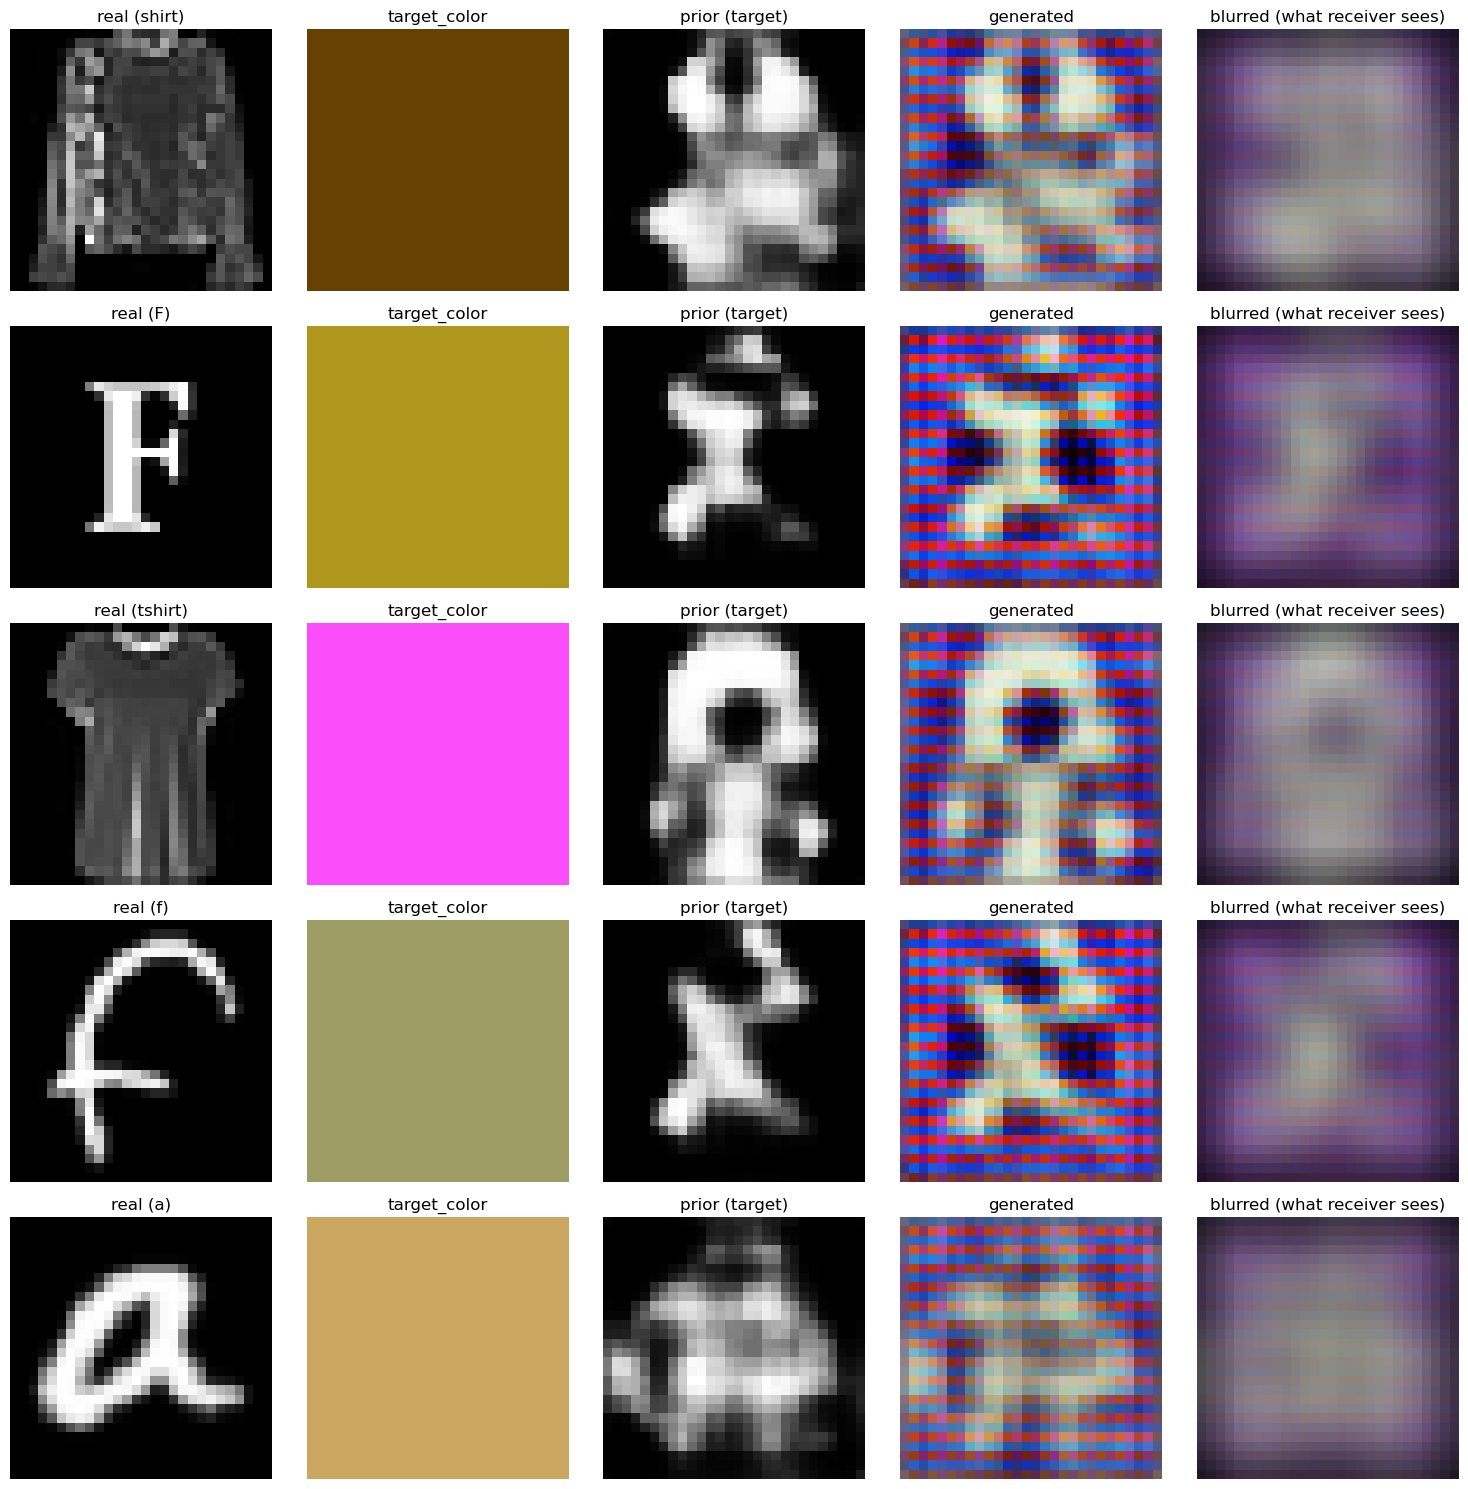

In [52]:
@torch.no_grad()
def show_painter_outputs(model, prior_lookup, dataset, n=5, device="cuda"):
    """
    For n random samples from the dataset, show:
      real glyph | target_color | prior (what painter is regressing toward) |
      generated | blurred generated
    """
    model.eval().to(device)
    
    fig, axes = plt.subplots(n, 5, figsize=(15, 3 * n))
    if n == 1:
        axes = axes[None, :]
    
    for row in range(n):
        idx = random.randint(0, len(dataset) - 1)
        comp, label, target_color = dataset[idx]
        label_int = int(label)
        
        # Real glyph
        real_glyph = comp[3]
        
        # Prior for this class
        prior = prior_lookup.sample(label_int)
        
        # Generate
        label_t  = torch.tensor([label_int], device=device)
        noise    = torch.randn(1, 2, device=device)
        onehot   = F.one_hot(label_t, num_classes=NUM_CLASSES).float()
        x        = torch.cat([onehot, noise], dim=1)
        generated = model(x)
        blurred_gen = box_blur(generated)
        
        # Plot
        axes[row, 0].imshow(real_glyph.cpu(), cmap="gray")
        axes[row, 0].set_title(f"real ({label_to_str(label_int)})")
        
        # target_color block
        tc_img = target_color.view(3, 1, 1).expand(3, 28, 28).permute(1, 2, 0).cpu()
        axes[row, 1].imshow(tc_img)
        axes[row, 1].set_title("target_color")
        
        # axes[row, 2].imshow(prior.squeeze().cpu(), cmap="gray")
        # axes[row, 2].set_title("prior (target)")
        prior_gray = prior.mean(dim=0)

        axes[row, 2].imshow(prior_gray.detach().cpu(), cmap="gray")
        axes[row, 2].set_title("prior (target)")
        
        axes[row, 3].imshow(generated.squeeze(0).permute(1, 2, 0).cpu().clamp(0, 1))
        axes[row, 3].set_title("generated")
        
        axes[row, 4].imshow(blurred_gen.squeeze(0).permute(1, 2, 0).cpu().clamp(0, 1))
        axes[row, 4].set_title("blurred (what receiver sees)")
        
        for ax in axes[row]:
            ax.axis("off")
    
    plt.tight_layout()
    plt.show()
    
def label_to_str(label):
    kind, key = CLASSES[label]
    if kind == "fmnist":
        return FMNIST[key]
    return key


show_painter_outputs(ex_03_05a_model, prior_lookup, ex03_05_trainset, n=5)

# Full Model!

Ok so now that we bootstrapped the prep network, we now feed this into a hider network. We'll let gradients bubble back from the traditional loss than we've had in previous models, but we'll just bump the learning rate for the prep network a ton, so it doesn't collapse into something degraded. 

In [76]:
#mnist classifier and data loading
#this remains a 3 channel classifier, as in both pre- and post-, we sum the image before classification
class LeNet3channel_allGlyphs(nn.Module):
    def __init__(self, num_classes=55):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 5, padding=2)   
        self.conv2 = nn.Conv2d(16, 32, 5)
        self.fc1   = nn.Linear(32*5*5, 240)
        self.fc2   = nn.Linear(240, 168)
        self.fc3   = nn.Linear(168, num_classes)
        self.dropout = nn.Dropout(0.2)
    def forward(self, x):
        x = F.avg_pool2d(F.relu(self.conv1(x)), 2)
        x = F.avg_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        return self.fc3(x)

ex_03_04a_model = LeNet3channel_allGlyphs().to(device)
ex_03_04a_model.load_state_dict(torch.load('../../Epic_3/EX_03_04/Model/A/EX_03_04a_final.pt', map_location=device, weights_only=True))
ex_03_04a_model.eval()



LeNet3channel_allGlyphs(
  (conv1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=800, out_features=240, bias=True)
  (fc2): Linear(in_features=240, out_features=168, bias=True)
  (fc3): Linear(in_features=168, out_features=55, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

In [93]:

class HideNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: 3 (substrate) + NUM_CLASSES (label map) channels
        #this feels weird but idk sorta makes sense. one hot would work too but then gotta deal with weird sizes. 
        # j makes the math clean. 
        in_channels = 3 + NUM_CLASSES
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),  # 28x28
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 3, 3, padding=1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.net(x)

class FullSystem(nn.Module):
    def __init__(self, painter, hider):
        super().__init__()
        self.painter = painter
        self.hider = hider
    
    def forward(self, label_onehot, noise):
        substrate = self.painter(torch.cat([label_onehot, noise], dim=1))
        # broadcast label for hider
        B = label_onehot.shape[0]
        label_map = label_onehot.view(B, -1, 1, 1).expand(B, -1, 28, 28)
        hider_input = torch.cat([substrate, label_map], dim=1)
        public = self.hider(hider_input)
        return public, substrate  # return both for diagnostics

def ex_03_05b_loss_fn(batch, model, epoch, total_epochs, mode="train", **kwargs):
    comp, label, target_color = batch
    real_glyph = comp[:, 3:].to(device)
    
    # === Forward ===
    noise   = torch.randn(label.shape[0], 2).to(device)
    onehot  = F.one_hot(label, num_classes=NUM_CLASSES).float()

    public, substrate = model(onehot, noise)

    # === Blur for receiver-side decoding ===
    blur_type = config.variants.b.blur_fn  # parameterized blur
    blurred_public = blur(public, blur_type, kernel_size=3)
    blurred_public_1d = blurred_public.mean(dim=1, keepdim=True)
    
    # pre-blur
    public_1d = public.mean(dim=1, keepdim=True)
    logits = ex_03_04a_model(public_1d)  # frozen pre-blur classifier
    probs  = F.softmax(logits, dim=1)
    conf_pre = probs[torch.arange(probs.shape[0]), label]  # (B,) confidence on correct class
    
    # post blur mse
    # Mask: only penalize within glyph region
    glyph_mask = (real_glyph > 0.5).float()
    diff_sq = (blurred_public_1d - real_glyph) ** 2
    post_loss = (diff_sq * glyph_mask).sum() / (glyph_mask.sum() + 1e-8)
    
    # no curriculum for now
    alpha = config.variants.b.alpha
    beta  = config.variants.b.beta
    loss = alpha * conf_pre.mean() + beta * post_loss
    
    if mode == "val":
        return {
            "val_loss":   loss.item(),
            "pre_loss":   conf_pre.mean().item(),
            "post_loss":  post_loss.item(),
        }
    return loss

# ── RUN ───────────────────────────────────────────────────────────────────────
EX_03_05b_info = {
    "exp_id":      "EX_03_05b",
    "epochs":      config.variants.b.epochs,
    "log_to":      "both", #"file" if you dont want wandb 
    "weights_dir": "Model/B",
    "log_dir":     "logs/B",
    "seed":        42,
    "notes": config.variants.b.description
}



In [94]:

ex_03_05b_hider = HideNetwork()
ex_03_05b_model = FullSystem(painter=ex_03_05a_model, hider=ex_03_05b_hider)

optimizer = torch.optim.Adam([
    {"params": ex_03_05b_model.painter.parameters(), "lr": config.variants.b.lr / 10},
    {"params": ex_03_05b_model.hider.parameters(),   "lr": config.variants.b.lr},
])

run_experiment(
    model=ex_03_05b_model,
    optimizer=optimizer,
    loss_fn=ex_03_05b_loss_fn,
    train_loader=ex03_05_trainloader,   # use the original loader, not the bootstrap wrapper
    val_loader=ex03_05_valloader,
    config=EX_03_05b_info,
    log_to=EX_03_05b_info["log_to"],
)

[device] using cuda


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
post_loss,█▇▇▆▅▅▅▅▃▃▃▃▂▃▂▂▂▁▁▁
pre_loss,█▆▅▄▄▃▅▄▂▃▃▂▃▄▂▂▃▂▁▃
train_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▆▆▅▅▅▅▃▃▃▃▂▃▂▂▂▁▁▁
epoch,20
post_loss,0.01416
pre_loss,0.00081
train_loss,0.0109
val_loss,0.01082


FullSystem(
  (painter): prepNetwork(
    (net): Sequential(
      (0): Linear(in_features=57, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=1568, bias=True)
      (3): ReLU()
      (4): Unflatten(dim=1, unflattened_size=(32, 7, 7))
      (5): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (6): ReLU()
      (7): ConvTranspose2d(16, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (8): Sigmoid()
    )
  )
  (hider): HideNetwork(
    (net): Sequential(
      (0): Conv2d(58, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): ReLU()
      (6): Conv2d(16, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): Sigmoid()
    )
  )
)

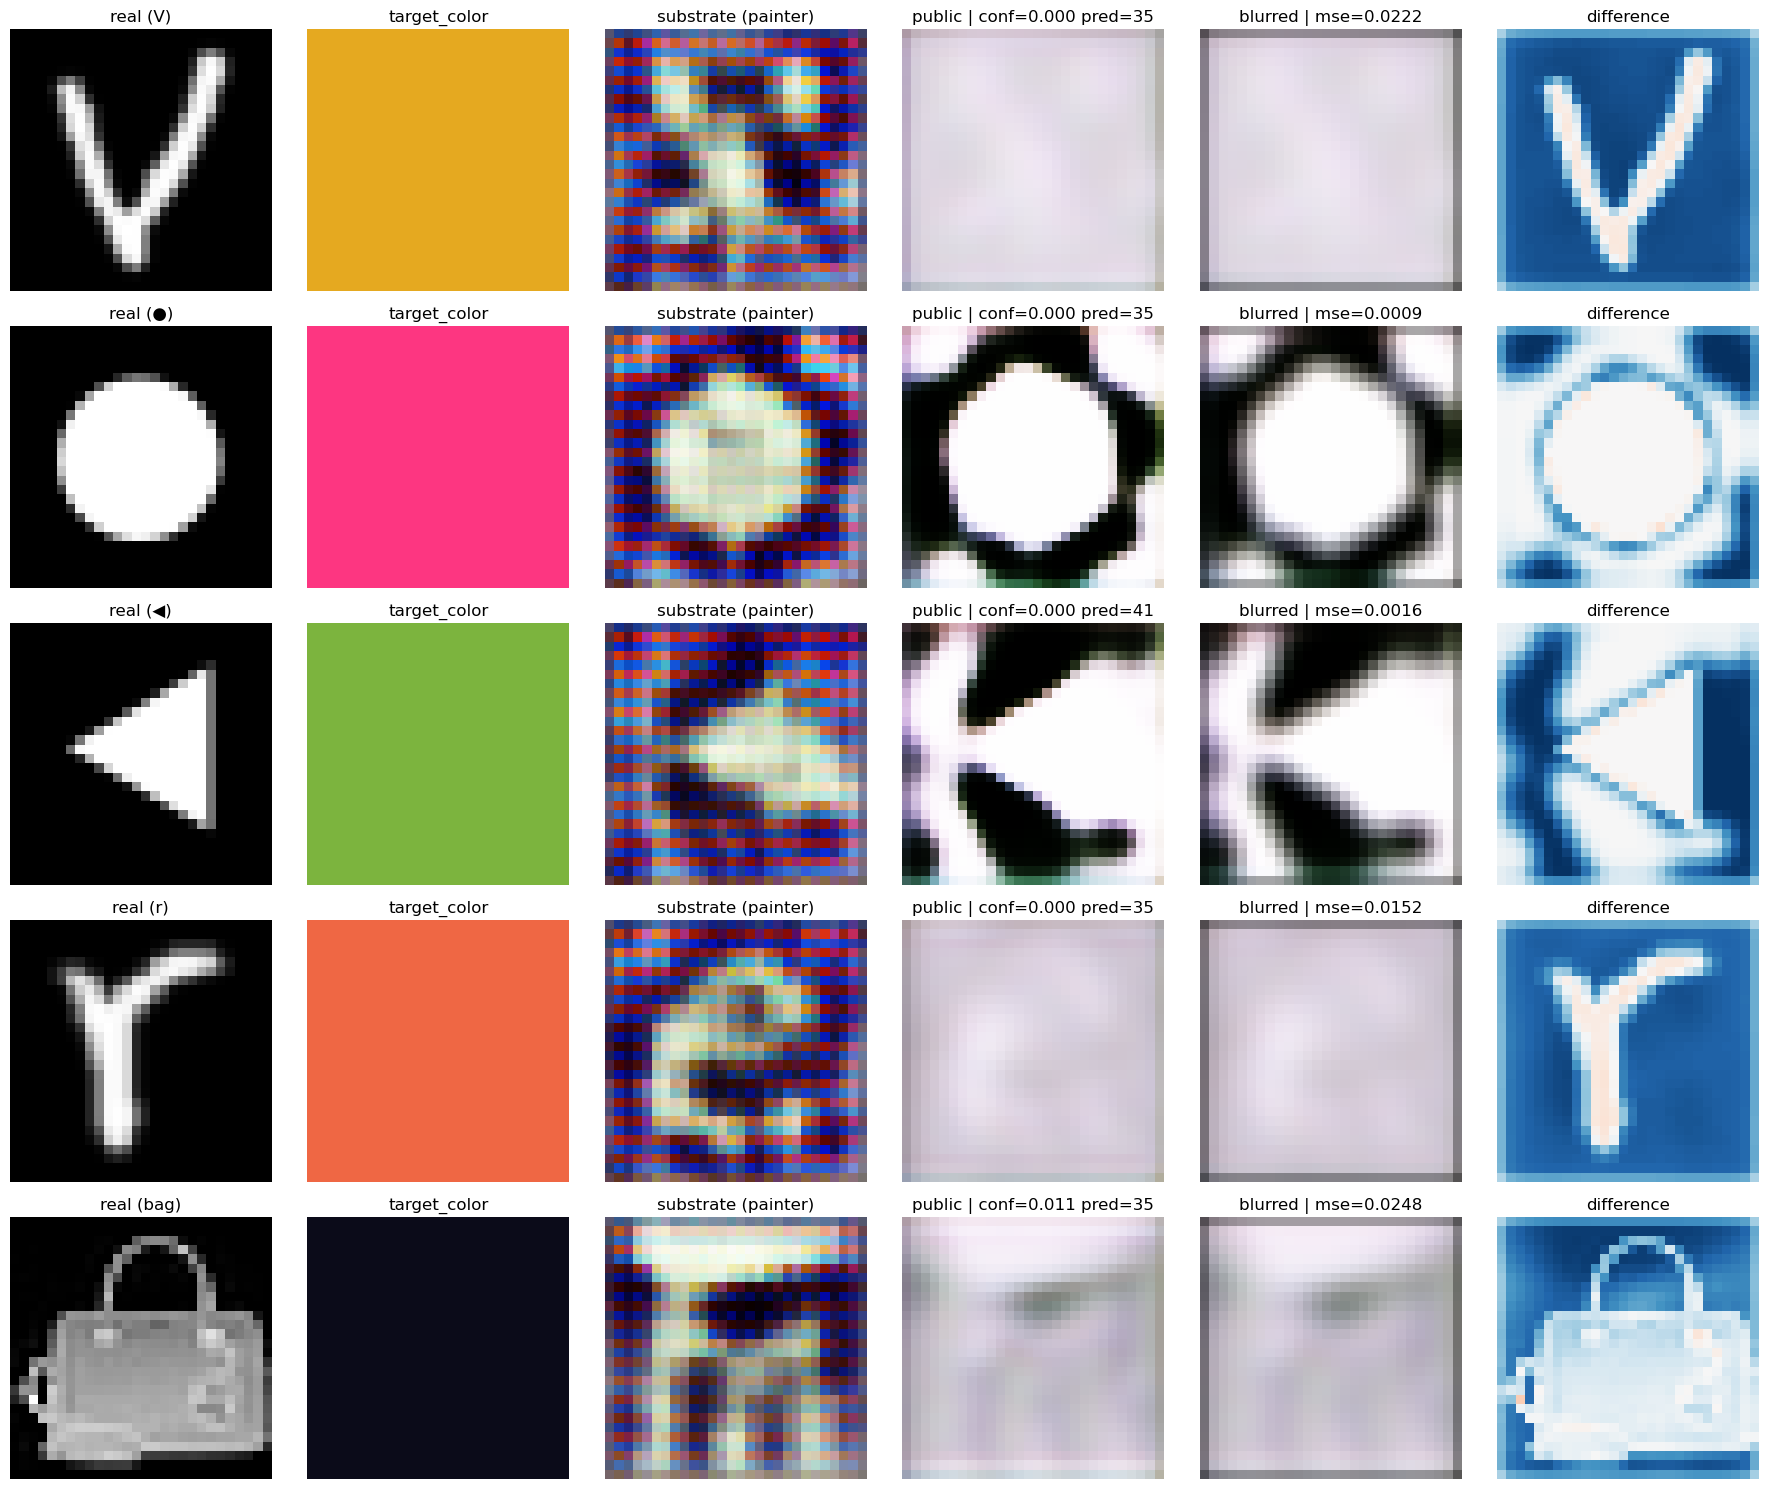

In [95]:
@torch.no_grad()
def show_full_system(model, dataset, n=5, blur_fn=None, device="cuda"):
    """
    Visualize the full painter -> hider pipeline.
    Columns: real glyph | target_color | substrate (painter) | public (hider) | blurred public | difference
    """
    model.eval().to(device)

    fig, axes = plt.subplots(n, 6, figsize=(18, 3 * n))
    if n == 1:
        axes = axes[None, :]
    
    for row in range(n):
        idx = random.randint(0, len(dataset) - 1)
        comp, label, target_color = dataset[idx]
        label_int = int(label)
        real_glyph = comp[3]
        
        # Forward through full system
        label_t = torch.tensor([label_int], device=device)
        noise   = torch.randn(1, 2, device=device)
        onehot  = F.one_hot(label_t, num_classes=NUM_CLASSES).float()
        public, substrate = model(onehot, noise)
        
        # Blur
        blur_type = config.variants.b.blur_fn  # parameterized blur
        blurred_public = blur(public, blur_type, kernel_size=3)
        blurred_public_1d = blurred_public.mean(dim=1, keepdim=True)
        
        # Confusion check on public
        public_1d = public.mean(dim=1, keepdim=True)
        logits = ex_03_04a_model(public_1d)
        probs  = F.softmax(logits, dim=1)
        conf_pre = probs[0, label_int].item()
        pred_pre = logits.argmax(dim=1).item()
        
        # Post-blur MSE (masked)
        glyph_mask = (real_glyph > 0.5).float()
        diff = (blurred_public_1d.squeeze().cpu() - real_glyph) ** 2
        post_loss = (diff * glyph_mask).sum() / (glyph_mask.sum() + 1e-8)
        
        # Plot
        axes[row, 0].imshow(real_glyph, cmap="gray")
        axes[row, 0].set_title(f"real ({label_to_str(label_int)})")
        
        tc_img = target_color.view(3, 1, 1).expand(3, 28, 28).permute(1, 2, 0)
        axes[row, 1].imshow(tc_img)
        axes[row, 1].set_title("target_color")
        
        axes[row, 2].imshow(substrate.squeeze(0).permute(1, 2, 0).cpu().clamp(0, 1))
        axes[row, 2].set_title("substrate (painter)")
        
        axes[row, 3].imshow(public.squeeze(0).permute(1, 2, 0).cpu().clamp(0, 1))
        axes[row, 3].set_title(f"public | conf={conf_pre:.3f} pred={pred_pre}")
        
        axes[row, 4].imshow(blurred_public.squeeze(0).permute(1, 2, 0).cpu().clamp(0, 1))
        axes[row, 4].set_title(f"blurred | mse={post_loss:.4f}")
        
        # Difference: blurred (1d) vs real glyph
        diff_vis = (blurred_public_1d.squeeze().cpu() - real_glyph)
        axes[row, 5].imshow(diff_vis, cmap="RdBu", vmin=-1, vmax=1)
        axes[row, 5].set_title("difference")
        
        for ax in axes[row]:
            ax.axis("off")
    
    plt.tight_layout()
    plt.show()


show_full_system(ex_03_05b_model, ex03_05_trainset, n=5)